In [4]:
import mlflow
import mlflow.sklearn
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded ✅")

All libraries loaded ✅


In [7]:
df = pd.read_csv("/home/a-akbar/Documents/crop_yield.csv",
                 nrows=50000)

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nFirst 3 rows:")
df.head(3)

Shape: (50000, 10)

Columns: ['Region', 'Soil_Type', 'Crop', 'Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used', 'Weather_Condition', 'Days_to_Harvest', 'Yield_tons_per_hectare']

First 3 rows:


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443


In [10]:
# Encode categorical columns
cat_cols = ['Region', 'Soil_Type', 'Crop', 'Weather_Condition']
le = LabelEncoder()

df_encoded = df.copy()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df[col])

# Convert booleans to int
df_encoded['Fertilizer_Used'] = df_encoded['Fertilizer_Used'].astype(int)
df_encoded['Irrigation_Used'] = df_encoded['Irrigation_Used'].astype(int)

# Features and target
X = df_encoded.drop('Yield_tons_per_hectare', axis=1)
y = df_encoded['Yield_tons_per_hectare']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Test samples    :", X_test.shape[0])
print("Features        :", list(X.columns))

Training samples: 40000
Test samples    : 10000
Features        : ['Region', 'Soil_Type', 'Crop', 'Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used', 'Weather_Condition', 'Days_to_Harvest']


In [12]:
mlflow.set_experiment("Crop_Yield_Prediction")

with mlflow.start_run(run_name="RandomForest_v1"):
    n_estimators = 100
    max_depth    = 10
    min_samples  = 5

    model = RandomForestRegressor(
        n_estimators     = n_estimators,
        max_depth        = max_depth,
        min_samples_leaf = min_samples,
        random_state     = 42,
        n_jobs           = -1)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    r2    = r2_score(y_test, preds)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))

    mlflow.log_param("n_estimators",     n_estimators)
    mlflow.log_param("max_depth",        max_depth)
    mlflow.log_param("min_samples_leaf", min_samples)
    mlflow.log_param("train_size",       X_train.shape[0])
    mlflow.log_metric("r2_score", r2)
    mlflow.log_metric("rmse",     rmse)
    mlflow.sklearn.log_model(model, "crop_yield_rf_model")

    print(f"R² Score : {r2:.4f}")
    print(f"RMSE     : {rmse:.4f} tons/hectare")
    print("Logged to MLflow ✅")

2026/04/23 16:06:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 16:06:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


R² Score : 0.9108
RMSE     : 0.5060 tons/hectare
Logged to MLflow ✅


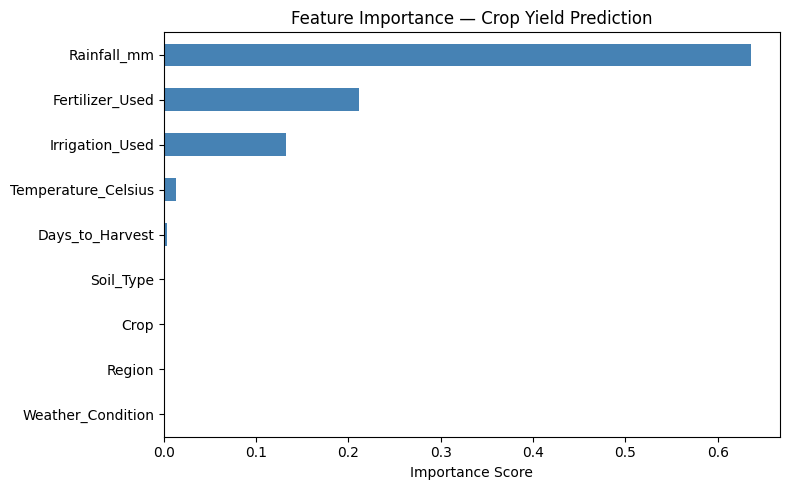

Feature importance saved & logged ✅


In [15]:
feat_imp = pd.Series(
    model.feature_importances_,
    index=X.columns).sort_values(ascending=True)

feat_imp.plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title("Feature Importance — Crop Yield Prediction")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
mlflow.log_artifact("feature_importance.png")
plt.show()
print("Feature importance saved & logged ✅")

In [14]:
mlflow.end_run()

mlflow.set_experiment("Crop_Yield_Prediction")

with mlflow.start_run(run_name="RandomForest_v2_deeper"):
    n_estimators = 200
    max_depth    = 20
    min_samples  = 2

    model2 = RandomForestRegressor(
        n_estimators     = n_estimators,
        max_depth        = max_depth,
        min_samples_leaf = min_samples,
        random_state     = 42,
        n_jobs           = -1)
    model2.fit(X_train, y_train)

    preds2 = model2.predict(X_test)
    r2_2   = r2_score(y_test, preds2)
    rmse_2 = np.sqrt(mean_squared_error(y_test, preds2))

    mlflow.log_param("n_estimators",     n_estimators)
    mlflow.log_param("max_depth",        max_depth)
    mlflow.log_param("min_samples_leaf", min_samples)
    mlflow.log_metric("r2_score", r2_2)
    mlflow.log_metric("rmse",     rmse_2)
    mlflow.sklearn.log_model(model2, "crop_yield_rf_v2")

    print(f"Run 2 — R² : {r2_2:.4f}")
    print(f"Run 2 — RMSE : {rmse_2:.4f}")
    print("Logged ✅")

2026/04/23 16:07:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 16:07:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run 2 — R² : 0.9058
Run 2 — RMSE : 0.5198
Logged ✅
